# Capstone Project 1: Working with NumPy Matrices (Multidimensional Data)
This notebook analyses adult body-measurement data from NHANES (2020 excerpt). All requested tasks are implemented using NumPy-first workflows, visualisations, correlation analysis, and concise interpretations.

## 1) Load the two datasets as NumPy matrices
The following code imports the required libraries, defines feature names, and reads the male and female NHANES files into two matrices named `male` and `female`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.set_printoptions(precision=3, suppress=True)
sns.set_theme(style='whitegrid')

columns = [
    'weight_kg',
    'height_cm',
    'upper_arm_length_cm',
    'upper_leg_length_cm',
    'arm_circumference_cm',
    'hip_circumference_cm',
    'waist_circumference_cm',
]

male = np.genfromtxt(
    'nhanes_adult_male_bmx_2020.csv',
    delimiter=',',
    comments='#',
    skip_header=1,
)

female = np.genfromtxt(
    'nhanes_adult_female_bmx_2020.csv',
    delimiter=',',
    comments='#',
    skip_header=1,
)

male = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]

print(f'male matrix shape: {male.shape}')
print(f'female matrix shape: {female.shape}')
print('male has 7 columns:', male.shape[1] == 7)
print('female has 7 columns:', female.shape[1] == 7)
print('First male record:', male[0])
print('First female record:', female[0])

male matrix shape: (4081, 7)
female matrix shape: (4221, 7)
male has 7 columns: True
female has 7 columns: True
First male record: [ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
First female record: [ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]


Both matrices load correctly and each row corresponds to one participant with seven body measurements.
These matrices are now the base for all subsequent tasks.

## 2) Histograms of female and male weight on a single figure
The next code cell creates two vertically stacked histograms using `matplotlib.pyplot.subplot` and enforces identical x-axis limits using `matplotlib.pyplot.xlim`.

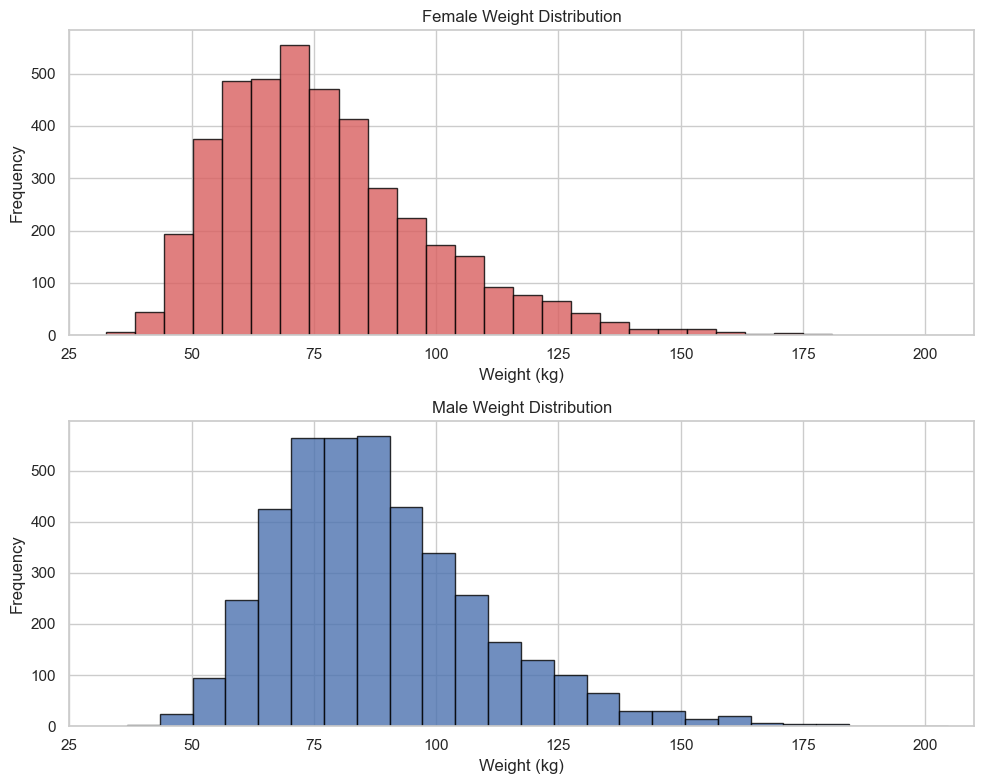

Shared x-axis limits: (25.0, 210.0)
Female mean / median weight: 77.40 / 73.60 kg
Male mean / median weight: 88.36 / 85.00 kg


In [2]:
female_weights = female[:, 0]
male_weights = male[:, 0]

x_min = np.floor(min(female_weights.min(), male_weights.min()) / 5) * 5 - 5
x_max = np.ceil(max(female_weights.max(), male_weights.max()) / 5) * 5 + 5

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=25, color='#d95f5f', edgecolor='black', alpha=0.8)
plt.title('Female Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.xlim(x_min, x_max)

plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=25, color='#4c72b0', edgecolor='black', alpha=0.8)
plt.title('Male Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.xlim(x_min, x_max)

plt.tight_layout()
plt.show()

print(f'Shared x-axis limits: ({x_min:.1f}, {x_max:.1f})')
print(f'Female mean / median weight: {female_weights.mean():.2f} / {np.median(female_weights):.2f} kg')
print(f'Male mean / median weight: {male_weights.mean():.2f} / {np.median(male_weights):.2f} kg')

Using a common x-range allows direct comparison between the two distributions. The printed means and medians provide a quick numerical complement to the histograms.

## 3) Box-and-whisker plot comparing female and male weights
This boxplot compares central tendency, spread, and potential outliers across the two groups.

C:\Users\thyag\AppData\Local\Temp\ipykernel_16420\718644199.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


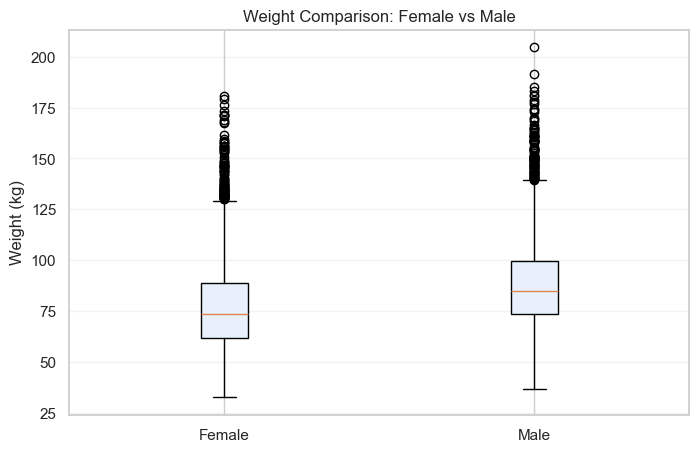

        Female  Male
Q1        61.6  73.3
Median    73.6  85.0
Q3        88.7  99.8
IQR       27.1  26.5


In [3]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [female_weights, male_weights],
    labels=['Female', 'Male'],
    patch_artist=True,
    boxprops={'facecolor': '#e8f1fb'},
)
plt.title('Weight Comparison: Female vs Male')
plt.ylabel('Weight (kg)')
plt.grid(axis='y', alpha=0.25)
plt.show()

def box_stats(x):
    q1, q2, q3 = np.percentile(x, [25, 50, 75])
    return pd.Series({'Q1': q1, 'Median': q2, 'Q3': q3, 'IQR': q3 - q1})

weight_box_summary = pd.DataFrame({
    'Female': box_stats(female_weights),
    'Male': box_stats(male_weights),
}).round(2)
print(weight_box_summary)

From the boxplot and quartiles, male weights show a higher median and a wider interquartile span. This indicates that, in this sample, men tend to weigh more and also display slightly greater variability.

## 4) Numerical aggregates of weight distributions (location, dispersion, shape)
The following code computes key summary statistics for female and male weights and then creates a short textual comparison.

In [4]:
def summarize_weight_distribution(x):
    return {
        'count': len(x),
        'mean': np.mean(x),
        'median': np.median(x),
        'std_dev': np.std(x, ddof=1),
        'variance': np.var(x, ddof=1),
        'range': np.ptp(x),
        'IQR': np.percentile(x, 75) - np.percentile(x, 25),
        'skewness': stats.skew(x, bias=False),
        'kurtosis_excess': stats.kurtosis(x, fisher=True, bias=False),
    }

female_summary = summarize_weight_distribution(female_weights)
male_summary = summarize_weight_distribution(male_weights)

summary_df = pd.DataFrame({'Female': female_summary, 'Male': male_summary}).round(3)
print(summary_df)

def skew_label(v):
    if v > 0.5:
        return 'right-skewed'
    if v < -0.5:
        return 'left-skewed'
    return 'approximately symmetric'

female_skew = skew_label(female_summary['skewness'])
male_skew = skew_label(male_summary['skewness'])
more_dispersion = 'Female' if female_summary['std_dev'] > male_summary['std_dev'] else 'Male'

print('\nInterpretive comparison:')
print(f"- Female distribution is {female_skew}.")
print(f"- Male distribution is {male_skew}.")
print(f"- {more_dispersion} weights show greater dispersion by standard deviation.")
print("- Positive skewness values indicate a longer right tail where extreme high-weight values occur.")

                   Female      Male
count            4221.000  4081.000
mean               77.404    88.365
median             73.600    85.000
std_dev            21.545    21.422
variance          464.190   458.883
range             148.300   167.800
IQR                27.100    26.500
skewness            1.034     0.985
kurtosis_excess     1.404     1.478

Interpretive comparison:
- Female distribution is right-skewed.
- Male distribution is right-skewed.
- Female weights show greater dispersion by standard deviation.
- Positive skewness values indicate a longer right tail where extreme high-weight values occur.


These aggregates provide a fuller comparison than plots alone. In practical terms, skewness indicates tail behaviour and dispersion metrics indicate consistency versus variability.

## 5) Add BMI as the 8th column of the female matrix
BMI is computed as weight (kg) divided by height (m) squared.

In [5]:
female_bmi = female[:, 0] / (female[:, 1] / 100) ** 2
female = np.column_stack([female, female_bmi])
female_columns = columns + ['BMI']

print('female matrix shape after adding BMI:', female.shape)
print(f"BMI mean: {female_bmi.mean():.2f}")
print(f"BMI median: {np.median(female_bmi):.2f}")
print(f"BMI min/max: {female_bmi.min():.2f} / {female_bmi.max():.2f}")

female matrix shape after adding BMI: (4221, 8)
BMI mean: 30.10
BMI median: 28.89
BMI min/max: 14.20 / 67.04


The female matrix now has eight columns, with BMI appended at the end. This added feature supports both standardisation and health-ratio analysis.

## 6) Standardise all female columns (z-scores) to create `zfemale`
Standardisation puts all variables on a common scale (mean 0, standard deviation 1).

In [6]:
female_means = female.mean(axis=0)
female_stds = female.std(axis=0, ddof=0)
zfemale = (female - female_means) / female_stds

print('zfemale shape:', zfemale.shape)
print('Column means (approx 0):')
print(np.round(zfemale.mean(axis=0), 4))
print('Column std devs (approx 1):')
print(np.round(zfemale.std(axis=0, ddof=0), 4))

zfemale_preview = pd.DataFrame(zfemale[:5], columns=female_columns)
print('\nFirst 5 standardized rows:')
print(zfemale_preview.round(3))

zfemale shape: (4221, 8)
Column means (approx 0):
[ 0.  0. -0. -0.  0. -0.  0. -0.]
Column std devs (approx 1):
[1. 1. 1. 1. 1. 1. 1. 1.]

First 5 standardized rows:
   weight_kg  height_cm  upper_arm_length_cm  upper_leg_length_cm  \
0      0.914      0.009               -0.567                1.133   
1      0.636     -1.053               -1.079               -1.293   
2     -0.204      0.151                0.584                0.262   
3     -0.729     -0.388                0.839               -0.765   
4     -1.021     -0.784               -0.610               -0.982   

   arm_circumference_cm  hip_circumference_cm  waist_circumference_cm    BMI  
0                 0.551                 1.083                   1.116  0.997  
1                 1.032                 1.045                   0.265  1.156  
2                -0.162                -0.191                  -0.373 -0.259  
3                -0.662                -0.524                  -0.459 -0.670  
4                -0.786 

The standardised matrix is ready for multivariate visualisation and correlation analysis. Equal scaling is particularly useful when comparing variables measured in different units.

## 7) Pairplot and correlation matrices for selected standardised female variables
Variables used: height, weight, waist circumference, hip circumference, and BMI.

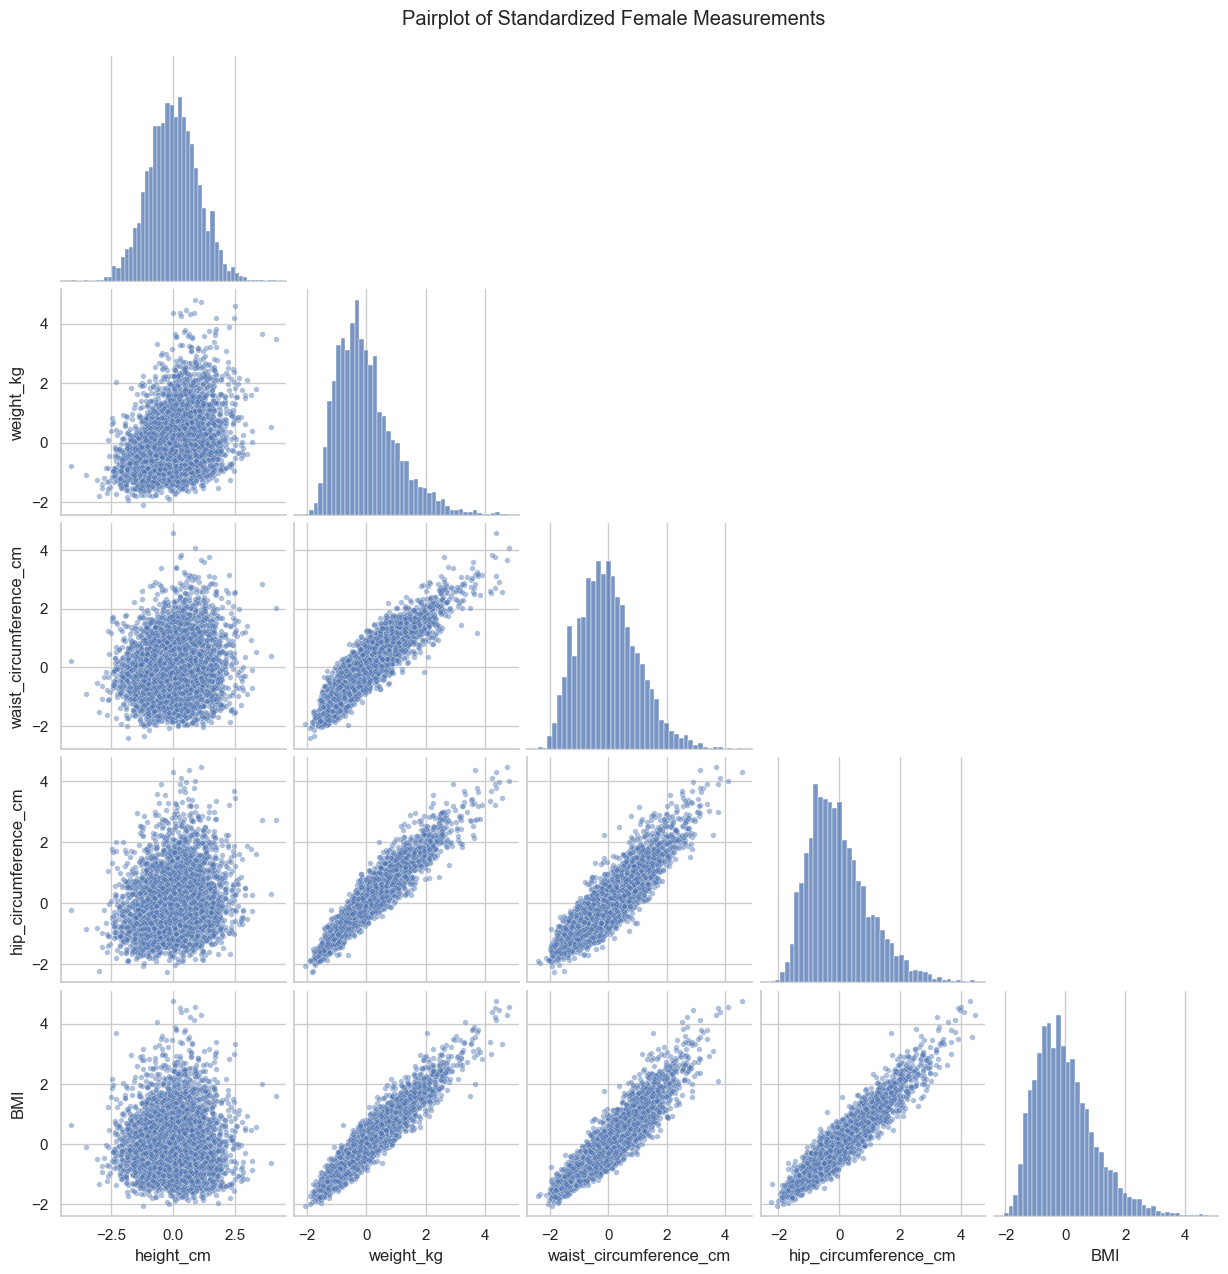

Pearson correlation matrix:
                        height_cm  weight_kg  waist_circumference_cm  \
height_cm                   1.000      0.345                   0.127   
weight_kg                   0.345      1.000                   0.905   
waist_circumference_cm      0.127      0.905                   1.000   
hip_circumference_cm        0.203      0.947                   0.897   
BMI                         0.033      0.946                   0.921   

                        hip_circumference_cm    BMI  
height_cm                              0.203  0.033  
weight_kg                              0.947  0.946  
waist_circumference_cm                 0.897  0.921  
hip_circumference_cm                   1.000  0.944  
BMI                                    0.944  1.000  

Spearman correlation matrix:
                        height_cm  weight_kg  waist_circumference_cm  \
height_cm                   1.000      0.339                   0.109   
weight_kg                   0.339      1.

In [7]:
selected_names = ['height_cm', 'weight_kg', 'waist_circumference_cm', 'hip_circumference_cm', 'BMI']
selected_indices = [1, 0, 6, 5, 7]

df_selected = pd.DataFrame(zfemale[:, selected_indices], columns=selected_names)

pair_grid = sns.pairplot(
    df_selected,
    corner=True,
    diag_kind='hist',
    plot_kws={'s': 16, 'alpha': 0.45}
)
pair_grid.fig.suptitle('Pairplot of Standardized Female Measurements', y=1.02)
plt.show()

pearson_corr = df_selected.corr(method='pearson')
spearman_corr = df_selected.corr(method='spearman')

print('Pearson correlation matrix:')
print(pearson_corr.round(3))
print('\nSpearman correlation matrix:')
print(spearman_corr.round(3))

def strongest_pair(corr_df):
    abs_corr = corr_df.abs().where(~np.eye(corr_df.shape[0], dtype=bool))
    i, j = np.unravel_index(np.nanargmax(abs_corr.values), abs_corr.shape)
    return corr_df.index[i], corr_df.columns[j], corr_df.iloc[i, j]

p_a, p_b, p_v = strongest_pair(pearson_corr)
s_a, s_b, s_v = strongest_pair(spearman_corr)
print(f"\nStrongest Pearson pair: {p_a} vs {p_b} = {p_v:.3f}")
print(f"Strongest Spearman pair: {s_a} vs {s_b} = {s_v:.3f}")

Both Pearson and Spearman correlations are useful: Pearson captures linear association, while Spearman captures monotonic association and is less sensitive to outliers. Typically, BMI is strongly associated with weight and waist/hip circumferences.

## 8) Add waist-to-height and waist-to-hip ratios to male and female matrices
These ratios are frequently used as anthropometric risk indicators.

In [8]:
male_whtr = male[:, 6] / male[:, 1]
male_whr = male[:, 6] / male[:, 5]
female_whtr = female[:, 6] / female[:, 1]
female_whr = female[:, 6] / female[:, 5]

male = np.column_stack([male, male_whtr, male_whr])
female = np.column_stack([female, female_whtr, female_whr])

male_columns_extended = columns + ['waist_to_height_ratio', 'waist_to_hip_ratio']
female_columns_extended = female_columns + ['waist_to_height_ratio', 'waist_to_hip_ratio']

print('male shape after ratio features:', male.shape)
print('female shape after ratio features:', female.shape)
print(f"Mean waist-to-height (female, male): {female_whtr.mean():.3f}, {male_whtr.mean():.3f}")
print(f"Mean waist-to-hip (female, male): {female_whr.mean():.3f}, {male_whr.mean():.3f}")

male shape after ratio features: (4081, 9)
female shape after ratio features: (4221, 10)
Mean waist-to-height (female, male): 0.616, 0.586
Mean waist-to-hip (female, male): 0.900, 0.971


Both matrices now include ratio-based features, enabling direct distribution-level comparison across sex groups.

## 9) Boxplots for ratio comparison (female vs male)
The following chart compares waist-to-height and waist-to-hip distributions side by side.

C:\Users\thyag\AppData\Local\Temp\ipykernel_16420\2258001272.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ratio_data, labels=labels, patch_artist=True)


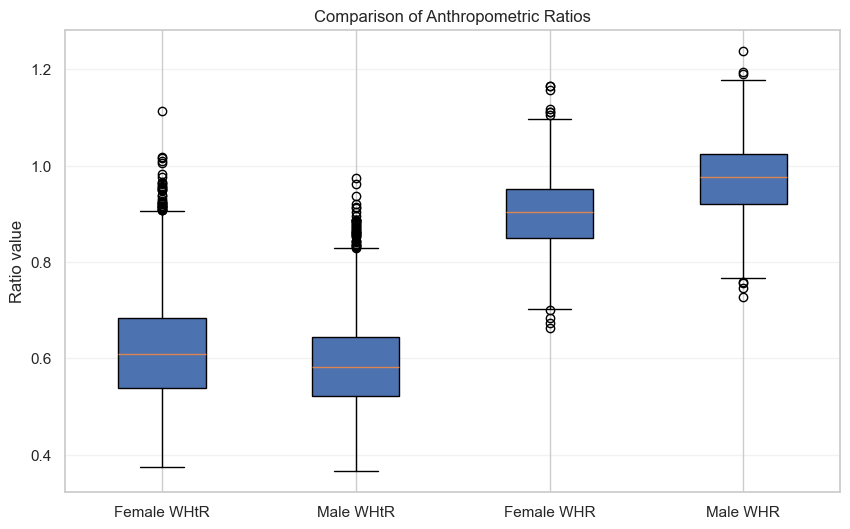

              Mean  Median    Std
Female WHtR  0.616   0.610  0.108
Male WHtR    0.586   0.582  0.094
Female WHR   0.900   0.903  0.072
Male WHR     0.971   0.977  0.077


In [9]:
ratio_data = [female_whtr, male_whtr, female_whr, male_whr]
labels = ['Female WHtR', 'Male WHtR', 'Female WHR', 'Male WHR']

plt.figure(figsize=(10, 6))
plt.boxplot(ratio_data, labels=labels, patch_artist=True)
plt.title('Comparison of Anthropometric Ratios')
plt.ylabel('Ratio value')
plt.grid(axis='y', alpha=0.25)
plt.show()

ratio_summary = pd.DataFrame({
    'Mean': [female_whtr.mean(), male_whtr.mean(), female_whr.mean(), male_whr.mean()],
    'Median': [
        np.median(female_whtr),
        np.median(male_whtr),
        np.median(female_whr),
        np.median(male_whr),
    ],
    'Std': [female_whtr.std(ddof=1), male_whtr.std(ddof=1), female_whr.std(ddof=1), male_whr.std(ddof=1)],
}, index=labels)

print(ratio_summary.round(3))

The boxplot reveals group-level differences in body-proportion indicators. In interpretation, compare medians (typical value), IQR (spread), and outlier concentration across all four boxes.

## 10) Advantages and disadvantages of BMI, waist-to-height ratio, and waist-to-hip ratio
**BMI**
- Advantages: simple to compute, widely adopted, useful for broad population screening.
- Disadvantages: does not directly separate fat mass from lean mass; can misclassify highly muscular individuals.

**Waist-to-height ratio (WHtR)**
- Advantages: captures central adiposity better than BMI in many settings; includes body-size normalisation via height.
- Disadvantages: sensitive to waist-measurement technique and less universally used in routine reporting than BMI.

**Waist-to-hip ratio (WHR)**
- Advantages: reflects fat distribution pattern (abdominal vs gluteofemoral), relevant for cardiometabolic risk.
- Disadvantages: can be influenced by both waist and hip measurement variability; interpretation may differ by sex and age group.

## 11) Print standardised body measurements for 5 lowest and 5 highest BMI females
The code below selects participants by BMI rank and prints their rows from `zfemale`.

In [10]:
bmi_col_idx = female_columns.index('BMI')  # index in female before ratio extensions (still valid)
bmi_sorted_idx = np.argsort(female[:, bmi_col_idx])
lowest_5_idx = bmi_sorted_idx[:5]
highest_5_idx = bmi_sorted_idx[-5:]
selected_idx = np.concatenate([lowest_5_idx, highest_5_idx])

selected_z = zfemale[selected_idx, :]
group = ['Lowest BMI'] * 5 + ['Highest BMI'] * 5

selected_df = pd.DataFrame(selected_z, columns=female_columns)
selected_df.insert(0, 'Participant_Row_Index', selected_idx)
selected_df.insert(1, 'Group', group)
selected_df.insert(2, 'Original_BMI', female[selected_idx, bmi_col_idx])

selected_df = selected_df.sort_values(by=['Group', 'Original_BMI'])
print('Standardized body measurements for the 5 lowest and 5 highest BMI females:')
print(selected_df.round(3).to_string(index=False))

Standardized body measurements for the 5 lowest and 5 highest BMI females:
 Participant_Row_Index       Group  Original_BMI  weight_kg  height_cm  upper_arm_length_cm  upper_leg_length_cm  arm_circumference_cm  hip_circumference_cm  waist_circumference_cm    BMI
                  2268 Highest BMI        64.199      4.247      0.292                1.862               -0.982                 2.369                 4.104                   3.817  4.396
                  3022 Highest BMI        64.707      4.456      0.505                1.692               -1.138                 3.350                 3.983                   2.903  4.462
                  1472 Highest BMI        65.115      4.349      0.278                2.843                1.942                 4.366                 3.919                   3.754  4.515
                  1104 Highest BMI        65.333      4.804      0.887                2.118                1.817                 3.778                 4.021                 

Participants in the highest-BMI group generally have positive z-scores for weight, waist, and hip circumference, while the lowest-BMI group tends to show negative z-scores on those same dimensions. This pattern is consistent with BMI’s mathematical dependence on body mass relative to height.

## 12) Final conclusion
The capstone-1 workflow has been completed end-to-end in one notebook: loading matrices, visual comparison, distribution statistics, BMI engineering, z-score standardisation, pairwise analysis, ratio-based comparisons, and ranked BMI profile inspection.